In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report
from xgboost import XGBRegressor, XGBClassifier
import matplotlib.pyplot as plt

In [5]:
#loading Dataset
df = pd.read_csv("final_dataset.csv")
print(df.shape)
df.head()

(1050, 15)


,TransactionID,Date,Time,Company,LocationID,City,FuelType,Quantity_Liters,Price_per_Litre,Total_Amount,PaymentMethod,VehicleType,LoyaltyCardUsed,PumpNumber,EmployeeID
0,TXN001,03-01-2024,05:44:00,HP,delhi-pump-04,delhi,petrol,26.30,94.46,2484.30,UPI,car,No,3,E-DEL-4
1,TXN002,04-02-2025,21:08:00,IOCL,pune-pump-01,pune,diesel,42.89,87.57,3755.88,Card,car,Yes,5,E-PUN-3
2,TXN003,25-08-2024,06:39:00,BPCL,mumbai-pump-02,mumbai,diesel,10.42,88.11,918.11,Card,bike,Yes,1,E-MUM-2
3,TXN004,05-01-2025,15:20:00,IOCL,bangalore-pump-07,bangalore,petrol,14.49,95.10,1378.00,Cash,bike,No,2,E-BAN-1
4,TXN005,09-04-2025,19:52:00,HP,mumbai-pump-02,mumbai,diesel,39.37,87.21,3433.46,Cash,car,No,5,E-MUM-5


In [ ]:
# Preprocessing

# Parse Date and Time
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Month'] = df['Date'].dt.month

# High Value Transaction Flag
df['HighValue'] = (df['Total_Amount'] > 4000).astype(int)

# Encode Categorical Variables
cat_cols = ['City','FuelType','VehicleType','PaymentMethod']
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Log Transform Target for Regression to handle spikes
df['log_Total_Amount'] = np.log1p(df['Total_Amount'])

# Features & Targets
features = ['Quantity_Liters','Price_per_Litre','City','FuelType','VehicleType',
            'PaymentMethod','Hour','DayOfWeek','Month']
X = df[features]
y_reg = df['log_Total_Amount']
y_clf = df['HighValue']

# Train-Test Split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)


In [7]:
# Regression Model: Predict Total Sales
reg_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
reg_model.fit(X_train_reg, y_train_reg)
y_pred_reg = reg_model.predict(X_test_reg)
y_pred_reg_actual = np.expm1(y_pred_reg)  # Convert back from log

# Regression Evaluation
mae = mean_absolute_error(np.expm1(y_test_reg), y_pred_reg_actual)
rmse = np.sqrt(mean_squared_error(np.expm1(y_test_reg), y_pred_reg_actual))
r2 = r2_score(np.expm1(y_test_reg), y_pred_reg_actual)
print("-----Regression Metrics-----")
print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))
print("R2:", round(r2,4))


-----Regression Metrics-----
MAE: 34.34
RMSE: 53.83
R2: 0.9982


In [8]:
# Classification Model: Predict High-Value Transactions
clf_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
clf_model.fit(X_train_clf, y_train_clf)
y_pred_clf = clf_model.predict(X_test_clf)

Evaluation
print("-----Classification Report-----")
print(classification_report(y_test_clf, y_pred_clf))

-----Classification Report-----
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       190
           1       1.00      0.95      0.97        20

    accuracy                           1.00       210
   macro avg       1.00      0.97      0.99       210
weighted avg       1.00      1.00      1.00       210



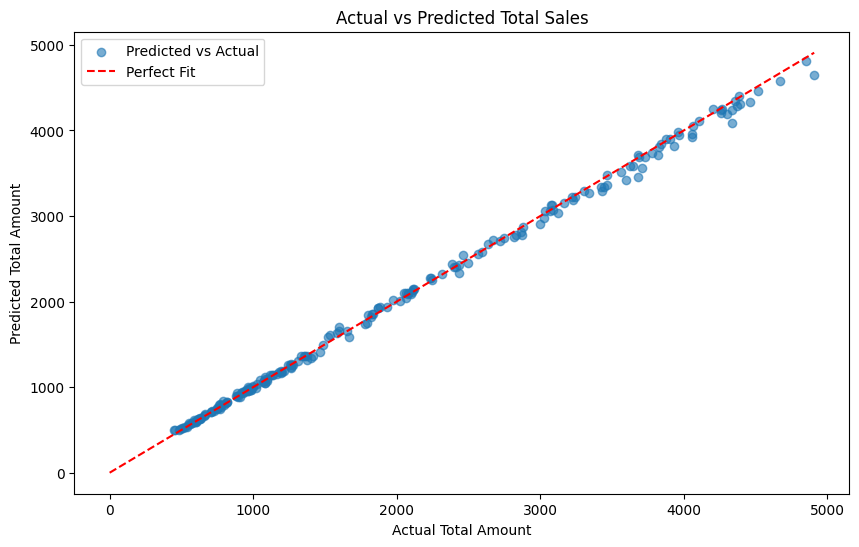

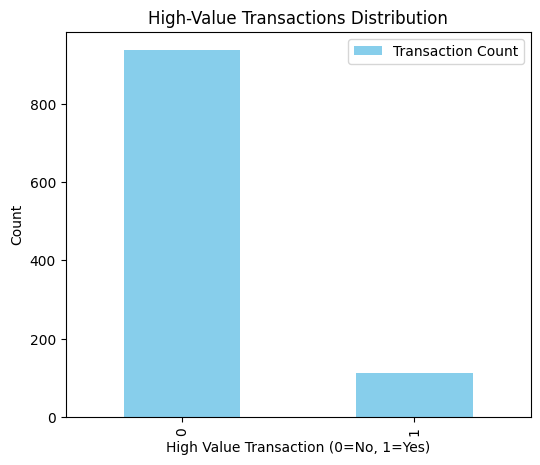

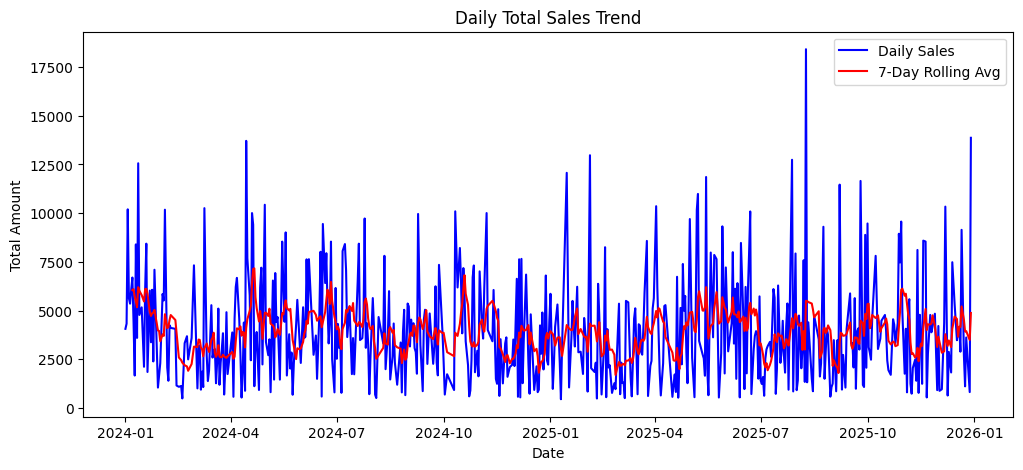

In [11]:
# Visualizations

# 1. Actual vs Predicted Total Sales
plt.figure(figsize=(10,6))
plt.scatter(np.expm1(y_test_reg), y_pred_reg_actual, alpha=0.6, label="Predicted vs Actual")
plt.plot([0, max(np.expm1(y_test_reg))], [0, max(np.expm1(y_test_reg))], color='red', linestyle='--', label="Perfect Fit")
plt.xlabel("Actual Total Amount")
plt.ylabel("Predicted Total Amount")
plt.title("Actual vs Predicted Total Sales")
plt.legend()
plt.show()

# 2. Distribution of High-Value Transactions
plt.figure(figsize=(6,5))
df['HighValue'].value_counts().plot(kind='bar', color='skyblue', label='Transaction Count')
plt.xlabel("High Value Transaction (0=No, 1=Yes)")
plt.ylabel("Count")
plt.title("High-Value Transactions Distribution")
plt.legend()
plt.show()

# 3. Total Sales Trend (Daily Rolling Average)
plt.figure(figsize=(12,5))
daily_sales = df.groupby('Date')['Total_Amount'].sum()
rolling_avg = daily_sales.rolling(7).mean()
plt.plot(daily_sales.index, daily_sales.values, label="Daily Sales", color='blue')
plt.plot(rolling_avg.index, rolling_avg.values, label="7-Day Rolling Avg", color='red')
plt.xlabel("Date")
plt.ylabel("Total Amount")
plt.title("Daily Total Sales Trend")
plt.legend()
plt.show()


In [ ]:
df['Predicted_Total_Amount'] = np.expm1(reg_model.predict(X))
df['Predicted_HighValue'] = clf_model.predict(X)
df.to_csv("fuel_predictions_for_powerbi.csv", index=False)